In [1]:
import polars as pl


from deq.plot import line_plot, grouped_bars
from spells import summon, ColSpec, ColType
from spells.config import all_sets

In [57]:
ext={
    "has_splash": ColSpec(col_type=ColType.GROUP_BY,
                          expr=pl.when(pl.col("splash_colors").is_null()).then(False).otherwise(True)),
    "deck_lands_gb": ColSpec(col_type=ColType.GROUP_BY, expr=lambda names: pl.sum_horizontal([pl.col(f"deck_lands_{name}") for name in names])),
     "deck_spells_hz": ColSpec(col_type=ColType.GROUP_BY, expr=lambda names: pl.sum_horizontal([pl.col(f"deck_spells_{name}") for name in names])),
     "deck_mv_hz": ColSpec(col_type=ColType.GROUP_BY, expr=lambda names: pl.sum_horizontal([pl.col(f"deck_mana_value_{name}") for name in names])),
     "deck_mv_ratio": ColSpec(col_type=ColType.GROUP_BY, expr=pl.col('deck_mv_hz') / pl.col('deck_spells_hz')),
     "deck_mv_class": ColSpec(col_type=ColType.GROUP_BY, expr=(pl.col("deck_mv_ratio") * 5).round() / 5)}


In [80]:
df = summon(all_sets, ["game_wr", "num_games"],
            group_by=["deck_lands_gb", "deck_mv_class"],
            extensions=ext, 
            filter_spec={'$and':[
                {'num_colors': 2},
                {"has_splash":False},
                {"player_cohort": "Top"}
            ]})

In [81]:
pivot = df.filter(  
    pl.col('num_games') > 5000).pivot(   
    on="deck_lands_gb", 
    index="deck_mv_class", 
    values="game_wr").sort(
    "deck_mv_class").rename(
    {'deck_mv_class': 'Deck Average Mana Value'})

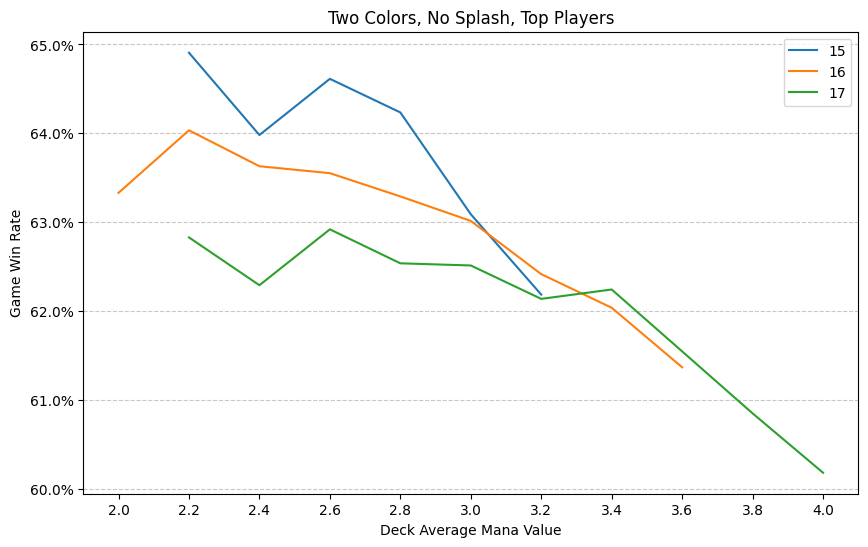

In [83]:
line_plot(
    pivot, 
    title="Two Colors, No Splash, Top Players",
    is_pct=True,
    y_label="Game Win Rate"
)


In [2]:
wr_df=summon(
    ["DFT", "FDN", "PIO", 
     "BLB", "OTJ", "DSK", "MH3",
    "MKM", "KTK", "LCI", "LTR", "WOE"
    ], ["game_wr"], group_by=["game_hour"],
      filter_spec={"player_cohort":"Top"} )



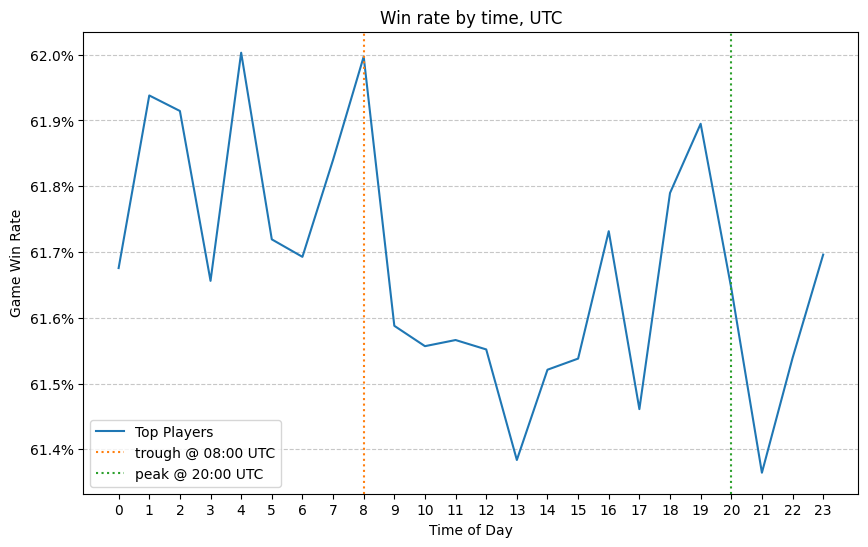

In [6]:
ax = line_plot(wr_df.rename({'game_wr': 'Top Players', 'game_hour': 'Time of Day'}), 
          title="Win rate by time, UTC",
          is_pct=True, 
          y_label="Game Win Rate",
          return_ax=True
    )


ax.axvline(x =8, color="#ff7f0e", linestyle=":", label="trough @ 08:00 UTC")
ax.axvline(x = 20, color="#2ca02c", linestyle=":", label="peak @ 20:00 UTC")
ax.legend()



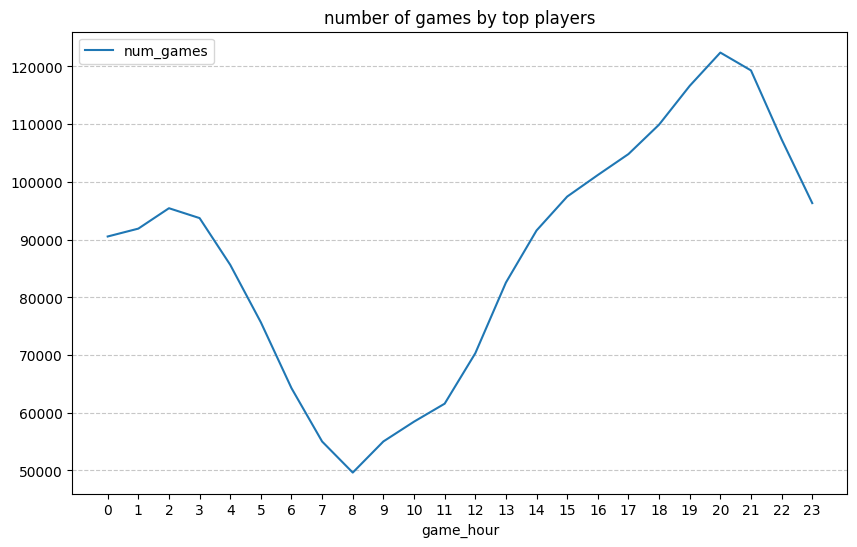

In [7]:
df=summon(
    ["DFT", "FDN", "PIO", 
     "BLB", "OTJ", "DSK", "MH3",
    "MKM", "KTK", "LCI", "LTR", "WOE"
    ], ["num_games"], group_by=["game_hour"],
      filter_spec={"player_cohort":"Top"} )
line_plot(df, title="number of games by top players")


In [49]:
summon(all_sets, ["deck_mana_value_avg"], group_by=[], filter_spec={'player_cohort':'Top'})

deck_mana_value_avg
f64
2.912826


In [17]:
from deq.mle import draft_equity
import polars as pl
from deq.plot import line_plot
import numpy as np

In [10]:
draft_equity('BLB', 1).pick_equity_df.select(['pick_num', -pl.col('remaining_pick_equity').diff()])

pick_num,remaining_pick_equity
i64,f64
0,null
1,0.009399
2,0.002747
3,0.000437
4,-0.001093
…,…
9,-0.005435
10,-0.006113
11,-0.006621


In [97]:
sets = ["MKM", "OTJ", "MH3", "BLB", "DSK", "FDN", "DFT"]
pick_equity_col = -pl.col('remaining_pick_equity').diff().alias('pick_equity_raw')
x = np.arange(1,15, dtype=np.int64)
df = pl.DataFrame({'pick_num': x})
for set_ in sets:
    df = df.join(draft_equity(set_, 1).pick_equity_df.select('pick_num', pick_equity_col).filter(pl.col('pick_num') > 0).rename({'pick_equity_raw': set_}), on = "pick_num", how="left")

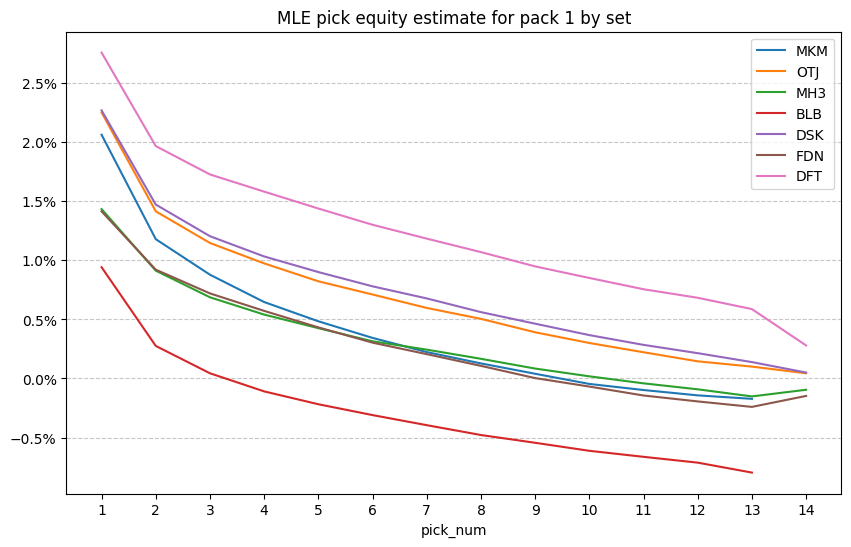

In [66]:
line_plot(df, title = "MLE pick equity estimate for pack 1 by set", is_pct=True)

In [99]:
    null_cards = draft_equity(set_, 1).df.filter(pl.col('q') <= 0).select('name')['name'].to_list()
    set_df = draft_equity(set_, 1, null_cards=null_cards).pick_equity_df.select('pick_num', pick_equity_col).filter(pl.col('pick_num') > 0)
    norm_val = set_df['pick_equity_raw'][13]
norm_val

0.005099699897566909

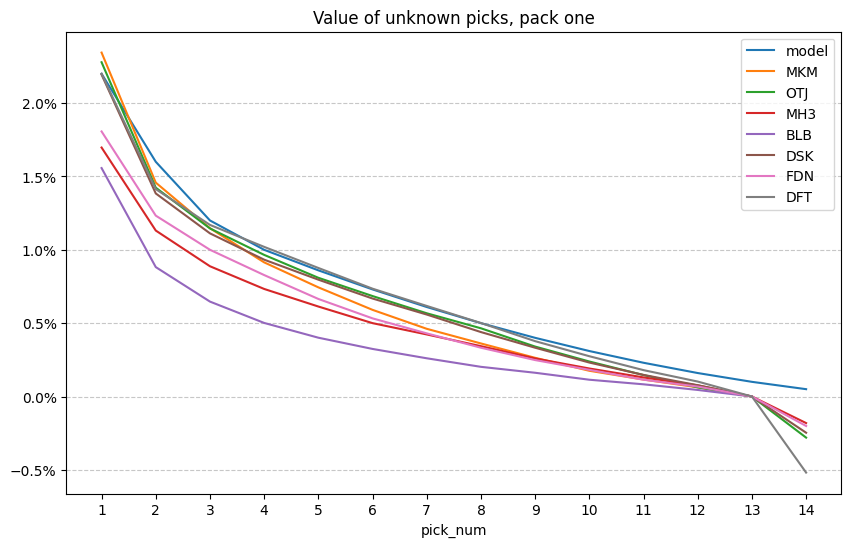

In [170]:
df = pl.DataFrame({'pick_num': x, 'model': y})
for set_ in sets:
    null_cards = draft_equity(set_, 1).df.filter(pl.col('q') <= 0).select('name')['name'].to_list()
    set_df = draft_equity(set_, 1, null_cards=null_cards).pick_equity_df.select('pick_num', pick_equity_col).filter(pl.col('pick_num') > 0)
    norm_val = set_df['pick_equity_raw'][12]
    df = df.join(set_df.select('pick_num', (pl.col('pick_equity_raw') - pl.lit(norm_val)).alias(set_)), on = "pick_num", how="left")

line_plot(df, is_pct=True, title="Value of unknown picks, pack one")

In [145]:
df['DSK']
a = np.array([0, .0006, .0013, .0021, .0030, .0040, .0051, .0062, .0074, .0087, .0101, .0125, .016, .022])
b = [a[13-i] for i in range(14)]

In [167]:
b = [0.022, 0.016, 0.012, 0.01, 0.0086, 0.0073, 0.0061, 0.005, 0.004, 0.0031, 0.0023, 0.0016, 0.0010, 0.0005]
np.polyfit(x[0:4], b[0:4], 2)

array([ 0.001, -0.009,  0.03 ])

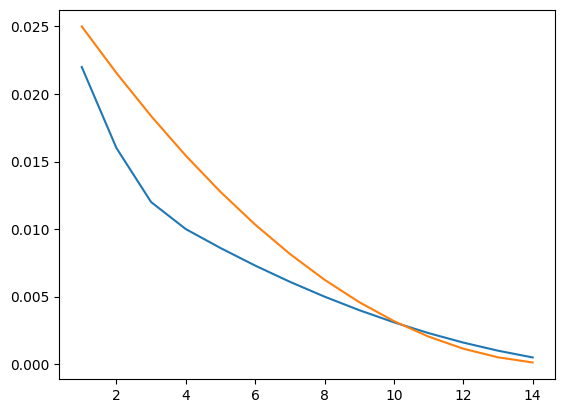

In [169]:
y = np.zeros(14)
y[0:4] = .001 * x[0:4] ** 2 - 0.009 * x[0:4] + 0.03
y[4:] = .00005 * x[4:] ** 2 - 0.00185 * x[4:] + 0.0166
plt.plot(x, y)
plt.plot(x, 0.025 * (1 - (x - 1)/14)**2)



In [95]:
pl.Config.set_tbl_rows(400)

polars.config.Config

In [96]:
result.df

name,q
str,f64
"""Sylvan Tutor""",0.041605
"""Valley Questcaller""",0.040922
"""Ygra, Eater of All""",0.040143
"""Dragonhawk, Fate's Tempest""",0.037207
"""Camellia, the Seedmiser""",0.034507
"""Season of Loss""",0.033475
"""Kitsa, Otterball Elite""",0.032523
"""Valley Mightcaller""",0.030688
"""Season of Gathering""",0.029024


In [183]:
from spells import summon

summon(
    "DFT", 
    ["picked_match_wr", "num_taken"],
    filter_spec={"$and": [
        {"pick_num": 1},
        {"pack_num":1},
        {"lhs": "format_day", "op": ">", "rhs":12}
    ]}).filter(pl.col("name").is_in([
    "Autarch Mammoth", "Bulwark Ox"]))



        

name,picked_match_wr,num_taken
str,f64,i32
"""Autarch Mammoth""",0.555511,1029
"""Bulwark Ox""",0.55005,407
